# Predicting User Satisfaction with AI Chatbots Using Machine Learning

Here we are importing libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 100)

###Loading the dataset
Datasets Link: https://www.kaggle.com/datasets/jawadaahmed/business-intelligence-chatbot-interaction-dataset?select=BI_Chatbot_Interactions.csv

In [36]:


df = pd.read_csv('/content/BI_Chatbot_Interactions.csv')

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (3200, 12)


,interaction_id,timestamp,department,user_role,user_query,query_category,metrics_requested,analysis_type,bot_response_confidence,response_time_ms,user_feedback_rating,estimated_business_impact
0,INT-100000,2025-08-12 08:29:31.851880,HR,Intern,Forecast next quarter revenue,Revenue,Revenue,Descriptive,0.73,2381,4.0,High
1,INT-100001,2025-10-08 15:20:31.851905,Operations,Analyst,Forecast next quarter revenue,Marketing,Profit Margin,Descriptive,0.89,635,2.0,Low
2,INT-100002,2025-09-21 01:42:31.851909,Finance,Manager,What is customer churn rate?,Marketing,Conversion Rate,Predictive,0.84,557,5.0,NaN
3,INT-100003,2025-09-07 01:43:31.851912,Operations,Analyst,Compare sales performance by region,Marketing,Conversion Rate,Trend Analysis,0.76,2499,4.0,NaN
4,INT-100004,2025-09-17 20:17:31.851914,Operations,Executive,Which campaign had highest ROI?,Marketing,Conversion Rate,Predictive,0.98,334,2.0,High


Understanding the dataset(INITIAL DATA EXPLORATION)


In [40]:


print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
['interaction_id', 'timestamp', 'department', 'user_role', 'user_query', 'query_category', 'metrics_requested', 'analysis_type', 'bot_response_confidence', 'response_time_ms', 'user_feedback_rating', 'estimated_business_impact']

Data types:


,Data Type
interaction_id,object
timestamp,object
department,object
user_role,object
user_query,object
query_category,object
metrics_requested,object
analysis_type,object
bot_response_confidence,float64
response_time_ms,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   interaction_id             3200 non-null   object 
 1   timestamp                  3200 non-null   object 
 2   department                 3200 non-null   object 
 3   user_role                  3200 non-null   object 
 4   user_query                 3200 non-null   object 
 5   query_category             3200 non-null   object 
 6   metrics_requested          3200 non-null   object 
 7   analysis_type              3200 non-null   object 
 8   bot_response_confidence    3200 non-null   float64
 9   response_time_ms           3200 non-null   int64  
 10  user_feedback_rating       2861 non-null   float64
 11  estimated_business_impact  2863 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 300.1+ KB

Missing values:


,Missing Values
user_feedback_rating,339
estimated_business_impact,337
interaction_id,0
timestamp,0
user_role,0
department,0
user_query,0
query_category,0
analysis_type,0
metrics_requested,0



Duplicate rows: 0


PreProcessing Data

In [77]:
# Removing duplicates
df = df.drop_duplicates().copy()

# Target variable
target_column = "satisfaction_group"
target_rating_original = "user_feedback_rating"

#  here we are converting and cleaning target
df[target_rating_original] = pd.to_numeric(df[target_rating_original], errors="coerce")
df = df.dropna(subset=[target_rating_original]).copy()
df = df[df[target_rating_original].isin([1, 2, 3, 4, 5])].copy()

# Map ratings to groups
rating_mapping = {1: "Low", 2: "Low", 3: "Neutral", 4: "High", 5: "High"}
df[target_column] = df[target_rating_original].map(rating_mapping)
df = df.dropna(subset=[target_column]).copy()

print("Dataset after basic cleaning:", df.shape)
print("\nSatisfaction group counts:")
print(df[target_column].value_counts(dropna=False))

Dataset after basic cleaning: (2861, 13)

Satisfaction group counts:
satisfaction_group
High       1242
Neutral     814
Low         805
Name: count, dtype: int64


### Checking the target variable

The target variable is `user_feedback_rating`.

The original rating contains values from 1 to 5. For the main classification task, the ratings are grouped into three satisfaction categories:

- **1–2 → Low**
- **3 → Neutral**
- **4–5 → High**

This creates a three-class classification problem and reduces the difficulty caused by treating every individual rating as a separate class.


In [39]:


target_rating = "user_feedback_rating"

if target_rating not in df.columns:
    raise ValueError(
        f"'{target_rating}' was not found in the dataset."
    )

print("Original rating distribution:")
display(
    df[target_rating]
    .value_counts(dropna=False)
    .sort_index()
)


Original rating distribution:


,count
user_feedback_rating,
1.0,295
2.0,510
3.0,814
4.0,762
5.0,480
NaN,339


### Exploring satisfaction distribution

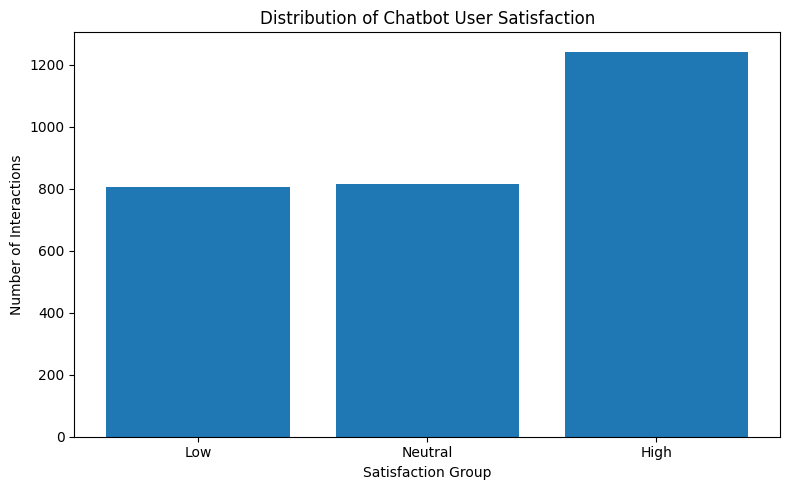

In [78]:

order = ["Low", "Neutral", "High"]
counts = df["satisfaction_group"].value_counts().reindex(order)

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.title("Distribution of Chatbot User Satisfaction")
plt.xlabel("Satisfaction Group")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

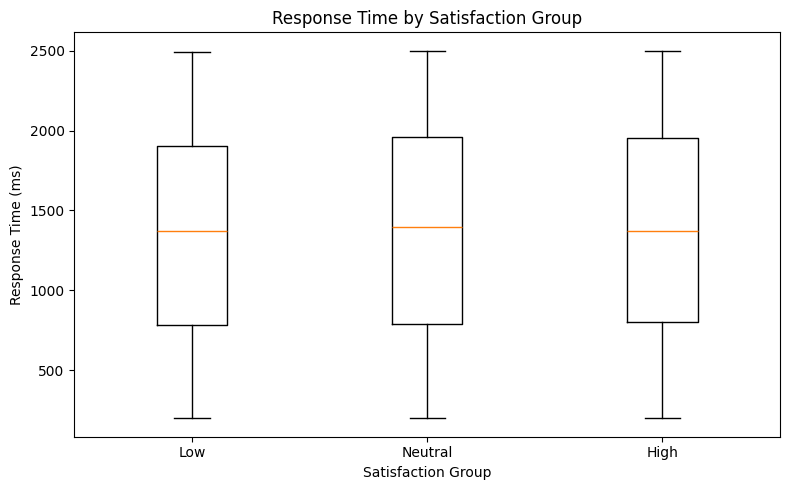

In [79]:
# Here we are seeing response time by satisfaction

if "response_time_ms" in df.columns:
    plt.figure(figsize=(8, 5))
    groups = [
        df.loc[df["satisfaction_group"] == group, "response_time_ms"].dropna()
        for group in order
    ]
    plt.boxplot(groups, labels=order)
    plt.title("Response Time by Satisfaction Group")
    plt.xlabel("Satisfaction Group")
    plt.ylabel("Response Time (ms)")
    plt.tight_layout()
    plt.show()


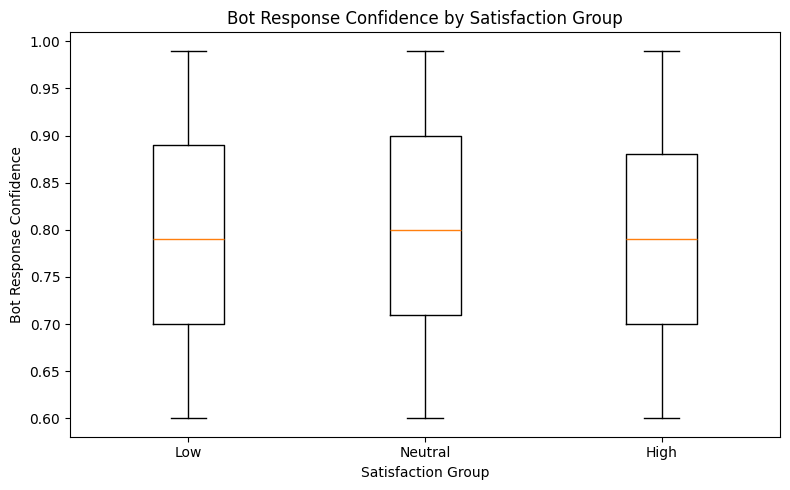

In [47]:
# Visualising bot confidence by satisfaction

if "bot_response_confidence" in df.columns:
    plt.figure(figsize=(8, 5))

    groups = [
        df.loc[
            df["satisfaction_group"] == group,
            "bot_response_confidence"
        ].dropna()
        for group in order
    ]

    plt.boxplot(groups, labels=order)

    plt.title("Bot Response Confidence by Satisfaction Group")
    plt.xlabel("Satisfaction Group")
    plt.ylabel("Bot Response Confidence")
    plt.tight_layout()
    plt.show()


### NUMERICAL FEATURE ANALYSIS

In [80]:
numeric_original = ["bot_response_confidence", "response_time_ms"]
available_numeric = [c for c in numeric_original if c in df.columns]

if available_numeric:
    display(
        df.groupby("satisfaction_group")[available_numeric]
        .agg(["mean", "median", "std"])
        .round(3)
    )

bot_response_confidence               response_time_ms  \
                                      mean median    std             mean   
satisfaction_group                                                          
High                                 0.791   0.79  0.111         1372.748   
Low                                  0.795   0.79  0.109         1352.262   
Neutral                              0.800   0.80  0.113         1378.869   

                                     
                    median      std  
satisfaction_group                   
High                1369.5  662.781  
Low                 1369.0  654.581  
Neutral             1398.0  680.108

##Preparing features


In [81]:
data = df.copy()

if "timestamp" in data.columns:
    data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")
    data["interaction_hour"] = data["timestamp"].dt.hour
    data["interaction_day_of_week"] = data["timestamp"].dt.dayofweek
    data["interaction_month"] = data["timestamp"].dt.month
    data["is_weekend"] = (data["interaction_day_of_week"] >= 5).astype(int)
    data = data.drop(columns=["timestamp"])

columns_to_remove = ["interaction_id", target_rating_original, "satisfaction_group"]
X = data.drop(columns=[c for c in columns_to_remove if c in data.columns]).copy()
y = data["satisfaction_group"].copy()

print("Number of features before encoding:", X.shape[1])
print("Number of observations:", len(X))

Number of features before encoding: 13
Number of observations: 2861


## Separating numerical and categorical features

In [49]:


numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['bot_response_confidence', 'response_time_ms', 'interaction_hour', 'interaction_day_of_week', 'interaction_month', 'is_weekend']

Categorical features:
['department', 'user_role', 'user_query', 'query_category', 'metrics_requested', 'analysis_type', 'estimated_business_impact']


## Train-test split

An 80/20 stratified split is used.


In [82]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 2288
Testing observations: 573


##Balancing the training data

The EDA showed that the target variable is imbalanced (High has more rows than Low and Neutral).

To fix this, we used SMOTE to balance the training data.

We only balance the training set, not the test set. This is because the test set should stay realistic to properly evaluate the model.

We also applied the preprocessor first to convert the text columns into numbers, because SMOTE cannot work with text.

In [74]:


from imblearn.over_sampling import SMOTE

# Fitting the preprocessor on the training data
preprocessor.fit(X_train)

# Transforming the training data into numbers
X_train_processed = preprocessor.transform(X_train)

# Checking the class counts before balancing
print("Before Balancing:")
print(y_train.value_counts())

# Applying SMOTE to the training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_processed,
    y_train
)

# Check the class counts after balancing
print("\nAfter Balancing:")
print(y_train_balanced.value_counts())

Before Balancing:
satisfaction_group
High       993
Neutral    651
Low        644
Name: count, dtype: int64

After Balancing:
satisfaction_group
Neutral    993
High       993
Low        993
Name: count, dtype: int64


## Building models on balanced data

After balancing the training data with SMOTE, we now train our machine learning models.

Because the preprocessor was already applied to the training data in SMOTE Section, we can fit the models directly on `X_train_balanced`.

For the test data, we still need to apply the same preprocessor so that the test data is in the same format as the training data.

The models we are using are:

- Baseline (majority class)
- Logistic Regression
- Random Forest
- Extra Trees

In [85]:
from sklearn.ensemble import ExtraTreesClassifier
X_test_processed = preprocessor.transform(X_test)

# Baseline Model

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train_balanced, y_train_balanced)
baseline_predictions = baseline_model.predict(X_test_processed)
print("Baseline model trained.")


# Logistic Regression

logistic_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    C=1.0,
    random_state=RANDOM_STATE
)
logistic_model.fit(X_train_balanced, y_train_balanced)
logistic_predictions = logistic_model.predict(X_test_processed)
print("Logistic Regression trained.")



# Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
random_forest_model.fit(X_train_balanced, y_train_balanced)
rf_predictions = random_forest_model.predict(X_test_processed)
print("Random Forest trained.")



# Extra Trees

extra_trees_model = ExtraTreesClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
extra_trees_model.fit(X_train_balanced, y_train_balanced)
extra_trees_predictions = extra_trees_model.predict(X_test_processed)
print("Extra Trees trained.")

Baseline model trained.
Logistic Regression trained.
Random Forest trained.
Extra Trees trained.


##Evaluating the models

After training the models, we now evaluate them on the test data.

We use the following metrics:

- Accuracy
- Precision (weighted)
- Recall (weighted)
- F1-score (weighted)
- F1-score (macro)

Macro F1 is very important here because it treats each satisfaction group equally, even if one group has fewer rows than the others.

In [76]:


def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (weighted)": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "Recall (weighted)": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "F1 (weighted)": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "F1 (macro)": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        )
    }


results = pd.DataFrame([
    evaluate_model("Baseline", y_test, baseline_predictions),
    evaluate_model("Logistic Regression", y_test, logistic_predictions),
    evaluate_model("Random Forest", y_test, rf_predictions),
    evaluate_model("Extra Trees", y_test, extra_trees_predictions)
])

display(results.round(3))

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro)
0,Baseline,0.435,0.189,0.435,0.263,0.202
1,Logistic Regression,0.332,0.352,0.332,0.337,0.327
2,Random Forest,0.382,0.352,0.382,0.337,0.305
3,Extra Trees,0.342,0.313,0.342,0.315,0.288


##Compare model performance visually

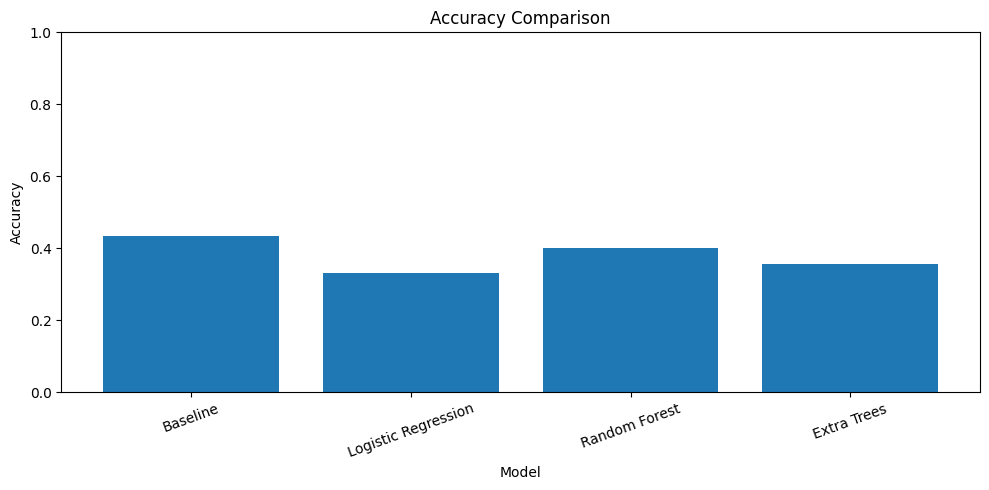

In [58]:


plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


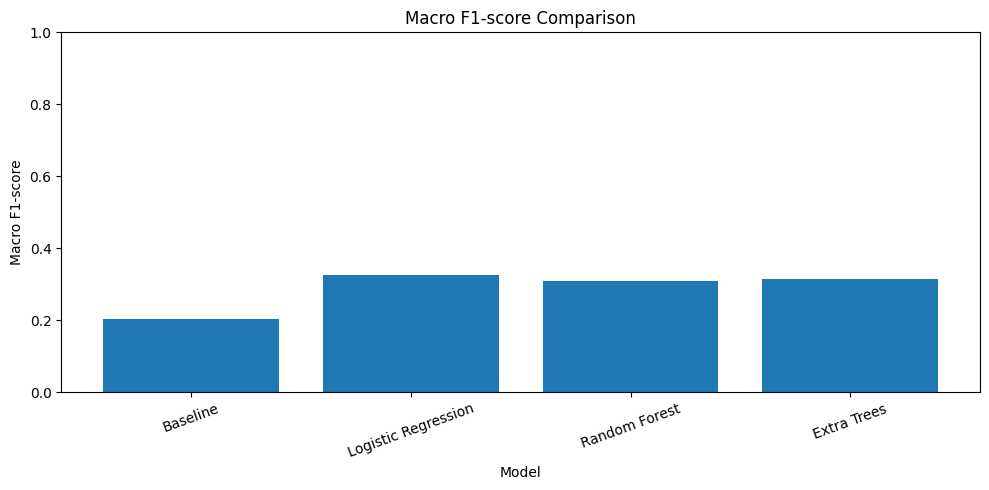

In [59]:
# Comparing macro F1

plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["F1 (macro)"]
)

plt.title("Macro F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()
